# 🦜 BirdCLEF 2026 - Pantanal Wildlife Sound Classification

**Competition:** [BirdCLEF+ 2026](https://www.kaggle.com/competitions/birdclef-2026)  
**Goal:** Identify wildlife species from passive acoustic monitoring recordings in the Brazilian Pantanal.  
**Model:** EfficientNet-B0 trained on Mel Spectrograms  
**Hardware:** Google Colab - A100 GPU  

---

## Approach Overview
1. Download competition data directly from Kaggle API
2. Mount Google Drive to persist model checkpoints across sessions
3. Explore and preprocess the dataset (35,549 recordings, 206 species classes)
4. Convert audio → Mel spectrograms (128 mel bins, 5-second windows)
5. Train EfficientNet-B0 using 5-fold stratified cross-validation
6. Save best model checkpoint and label encoder to Google Drive

## Step 1 - Verify GPU & Mount Google Drive

Confirm A100 is allocated and mount Google Drive to persist models across sessions.

In [ ]:
import torch

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DRIVE_DIR  = Path('/content/drive/MyDrive/birdclef2026')
MODELS_DIR = DRIVE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f'\nDrive model directory ready: {MODELS_DIR}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : NVIDIA A100-SXM4-40GB
VRAM            : 42.4 GB
Mounted at /content/drive

Drive model directory ready: /content/drive/MyDrive/birdclef2026/models


## Installing Dependencies

In [ ]:
# Force install the latest kaggle package
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.20
    Uninstalling kagglesdk-0.1.20:
      Successfully uninstalled kagglesdk-0.1.20
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
from google.colab import userdata
key = userdata.get('KAGGLE_KEY')
print(f"Key length  : {len(key)}")
print(f"Key preview : {key[:6]}...")

Key length  : 37
Key preview : KGAT_0...


In [ ]:
!pip install -q librosa soundfile timm
print('All dependencies installed.')

All dependencies installed.


In [ ]:
import os, requests, zipfile
from google.colab import userdata
from pathlib import Path
from tqdm import tqdm

KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME').strip()
KAGGLE_KEY      = userdata.get('KAGGLE_KEY').strip()

Path('/content/data').mkdir(parents=True, exist_ok=True)

# New KGAT_ tokens use Bearer auth, not Basic auth
headers = {
    'Authorization': f'Bearer {KAGGLE_KEY}',
    'Content-Type':  'application/json',
}

# New API endpoint format
url = 'https://www.kaggle.com/api/v1/competitions/data/download-all/birdclef-2026'

print('Testing auth...')
test = requests.get(
    'https://www.kaggle.com/api/v1/competitions/list',
    headers=headers
)
print(f'Auth test status: {test.status_code}')

if test.status_code == 200:
    print('Auth working! Starting download...')
    response = requests.get(url, headers=headers, stream=True)
    print(f'Download status: {response.status_code}')

    if response.status_code == 200:
        zip_path = '/content/data/birdclef-2026.zip'
        total    = int(response.headers.get('content-length', 0))

        with open(zip_path, 'wb') as f, tqdm(
            total=total, unit='B', unit_scale=True, desc='Downloading'
        ) as bar:
            for chunk in response.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk)
                bar.update(len(chunk))

        print('Download complete. Extracting...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall('/content/data/birdclef-2026/')
        print('Done.')
    else:
        print(f'Download error: {response.text[:300]}')
else:
    print(f'Auth failed: {test.text[:300]}')

Testing auth...
Auth test status: 200
Auth working! Starting download...
Download status: 200


Downloading: 100%|██████████| 16.1G/16.1G [01:06<00:00, 241MB/s]


Download complete. Extracting...
Done.


In [ ]:
import os, ast, pickle, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# ── Data paths ────────────────────────────────────────────────────────────
DATA_DIR                    = Path('/content/data/birdclef-2026')
TRAIN_AUDIO_DIR             = DATA_DIR / 'train_audio'
TRAIN_SOUNDSCAPES_DIR       = DATA_DIR / 'train_soundscapes'
TEST_SOUNDSCAPES_DIR        = DATA_DIR / 'test_soundscapes'
TRAIN_CSV                   = DATA_DIR / 'train.csv'
TAXONOMY_CSV                = DATA_DIR / 'taxonomy.csv'
TRAIN_SOUNDSCAPE_LABELS_CSV = DATA_DIR / 'train_soundscapes_labels.csv'
SAMPLE_SUBMISSION_CSV       = DATA_DIR / 'sample_submission.csv'

# ── Drive output paths ────────────────────────────────────────────────────
DRIVE_DIR          = Path('/content/drive/MyDrive/birdclef2026')
MODEL_SAVE_PATH    = DRIVE_DIR / 'models' / 'efficientnet_b0_fold0.pth'
LABEL_ENCODER_PATH = DRIVE_DIR / 'models' / 'label_encoder.pkl'

# ── Device ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Verify all paths
for name, p in [
    ('DATA_DIR',                    DATA_DIR),
    ('TRAIN_AUDIO_DIR',             TRAIN_AUDIO_DIR),
    ('TRAIN_CSV',                   TRAIN_CSV),
    ('TAXONOMY_CSV',                TAXONOMY_CSV),
    ('TRAIN_SOUNDSCAPES_DIR',       TRAIN_SOUNDSCAPES_DIR),
    ('TEST_SOUNDSCAPES_DIR',        TEST_SOUNDSCAPES_DIR),
    ('TRAIN_SOUNDSCAPE_LABELS_CSV', TRAIN_SOUNDSCAPE_LABELS_CSV),
    ('SAMPLE_SUBMISSION_CSV',       SAMPLE_SUBMISSION_CSV),
]:
    status = '✓' if p.exists() else '✗ MISSING'
    print(f'{name:35s}: {status}')

print(f'\nDevice: {DEVICE}')

DATA_DIR                           : ✓
TRAIN_AUDIO_DIR                    : ✓
TRAIN_CSV                          : ✓
TAXONOMY_CSV                       : ✓
TRAIN_SOUNDSCAPES_DIR              : ✓
TEST_SOUNDSCAPES_DIR               : ✓
TRAIN_SOUNDSCAPE_LABELS_CSV        : ✓
SAMPLE_SUBMISSION_CSV              : ✓

Device: cuda


## Step 5 - Load CSVs & Explore the Dataset

Load the three key metadata files:
- **train.csv** — 35,549 recordings with species labels, geolocation, and collection source
- **taxonomy.csv** — full taxonomic hierarchy for all 234 species
- **sample_submission.csv** — defines the prediction format (one column per species per 5-second window)

In [ ]:
train_df      = pd.read_csv(TRAIN_CSV)
taxonomy_df   = pd.read_csv(TAXONOMY_CSV)
sample_sub_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)

print('train_df shape     :', train_df.shape)
print('taxonomy_df shape  :', taxonomy_df.shape)
print('sample_sub_df shape:', sample_sub_df.shape)
print('\nTrain columns:', train_df.columns.tolist())
train_df.head(3)

train_df shape     : (35549, 15)
taxonomy_df shape  : (234, 5)
sample_sub_df shape: (3, 235)

Train columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


Unique species            : 206
Total training recordings : 35549

Class breakdown by taxonomy:
class_name
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1
Name: count, dtype: int64

Top 10 most common species:
primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
coffal1    495
osprey     495
socfly1    494
compau     493
yeofly1    493
Name: count, dtype: int64


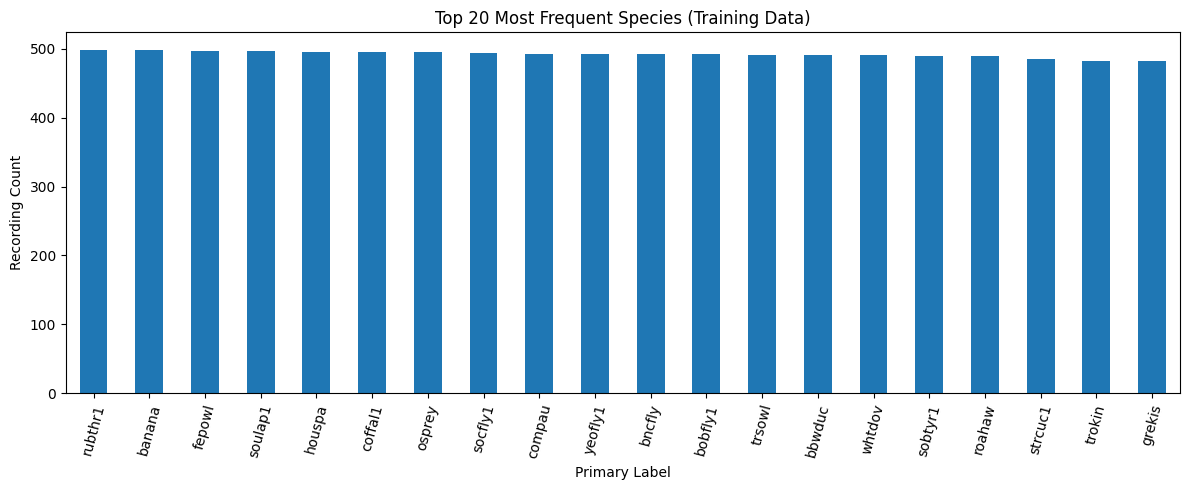

In [ ]:
# Class distribution analysis
label_counts = train_df['primary_label'].value_counts()

print(f'Unique species            : {train_df["primary_label"].nunique()}')
print(f'Total training recordings : {len(train_df)}')
print(f'\nClass breakdown by taxonomy:')
print(train_df['class_name'].value_counts())
print(f'\nTop 10 most common species:')
print(label_counts.head(10))

plt.figure(figsize=(12, 5))
label_counts.head(20).plot(kind='bar')
plt.title('Top 20 Most Frequent Species (Training Data)')
plt.xlabel('Primary Label')
plt.ylabel('Recording Count')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

 ## Step 6 - Audio File Discovery & Sample Inspection

Scan all `.ogg` files in the training directory and inspect one sample recording.  
Also sample 500 files to understand duration distribution — this informs the 5-second chunk choice.

Total .ogg files found: 35549

Example file  : iNat55393.ogg
Sample rate   : 32000
Duration      : 17.47s


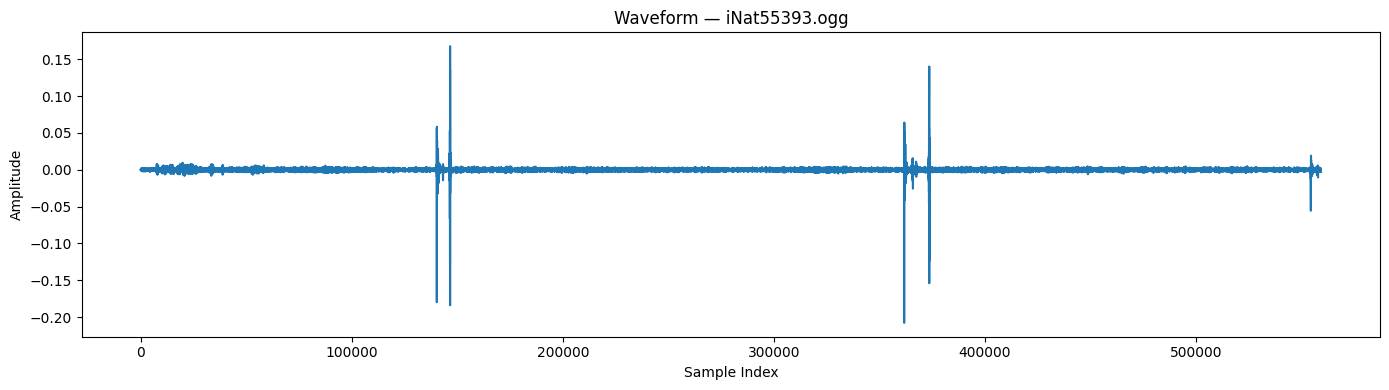

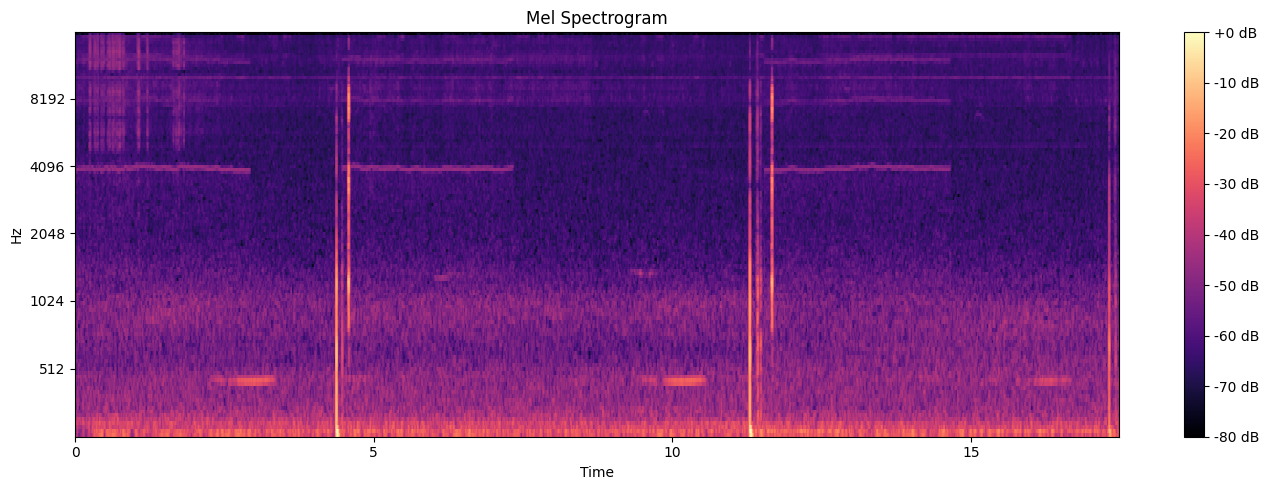

In [ ]:
audio_files = list(TRAIN_AUDIO_DIR.rglob('*.ogg'))
print(f'Total .ogg files found: {len(audio_files)}')

example_file = audio_files[0]
audio, sr = librosa.load(example_file, sr=32000, mono=True)
print(f'\nExample file  : {example_file.name}')
print(f'Sample rate   : {sr}')
print(f'Duration      : {len(audio)/sr:.2f}s')

# Waveform
plt.figure(figsize=(14, 4))
plt.plot(audio)
plt.title(f'Waveform — {example_file.name}')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# Mel spectrogram
mel_spec    = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmin=20, fmax=16000)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
plt.figure(figsize=(14, 5))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', fmin=20, fmax=16000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()


Min    : 0.29s
Max    : 3889.06s
Mean   : 41.50s
Median : 21.34s


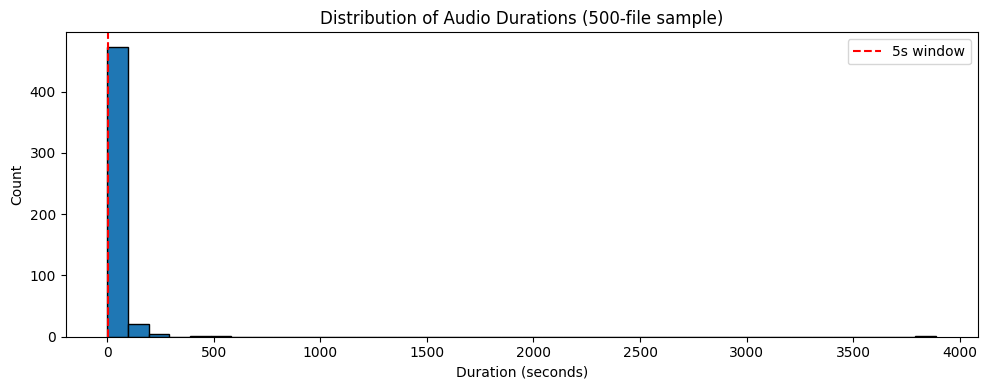

In [ ]:
# Duration distribution (500-file sample for speed)
sample_files = random.sample(audio_files, min(500, len(audio_files)))
durations = []
for f in sample_files:
    try:
        durations.append(sf.info(str(f)).duration)
    except Exception as e:
        print(f'Error: {f} — {e}')

durations = np.array(durations)
print(f'Min    : {durations.min():.2f}s')
print(f'Max    : {durations.max():.2f}s')
print(f'Mean   : {durations.mean():.2f}s')
print(f'Median : {np.median(durations):.2f}s')

plt.figure(figsize=(10, 4))
plt.hist(durations, bins=40, edgecolor='black')
plt.axvline(5, color='red', linestyle='--', label='5s window')
plt.title('Distribution of Audio Durations (500-file sample)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


## Step 7 - Build Audio Paths & Validate Files

Construct absolute paths for every training row and confirm the file exists on disk.
All 35,549 recordings should be present after the Kaggle download.

In [ ]:
train_df['audio_path']  = train_df['filename'].apply(lambda x: TRAIN_AUDIO_DIR / str(x))
train_df['file_exists'] = train_df['audio_path'].apply(lambda x: x.exists())

print(train_df['file_exists'].value_counts())

train_df = train_df[train_df['file_exists']].copy()
print(f'\nFiltered train_df shape: {train_df.shape}')
train_df[['primary_label', 'common_name', 'filename', 'file_exists']].head()

file_exists
True    35549
Name: count, dtype: int64

Filtered train_df shape: (35549, 17)


,primary_label,common_name,filename,file_exists
0,1161364,Guyalna cuta,1161364/iNat1216197.ogg,True
1,1161364,Guyalna cuta,1161364/iNat1114648.ogg,True
2,1161364,Guyalna cuta,1161364/iNat810195.ogg,True
3,1161364,Guyalna cuta,1161364/iNat818781.ogg,True
4,1161364,Guyalna cuta,1161364/iNat556514.ogg,True


## Step 8 - Audio Inspection Helper

A utility function that prints metadata and renders waveform + mel spectrogram for any DataFrame row.  
Useful for spot-checking specific species or debugging audio loading issues.

primary_label       : 1161364
common_name         : Guyalna cuta
scientific_name     : Guyalna cuta
class_name          : Insecta
collection          : iNat
rating              : 0.0
Duration            : 18.02s


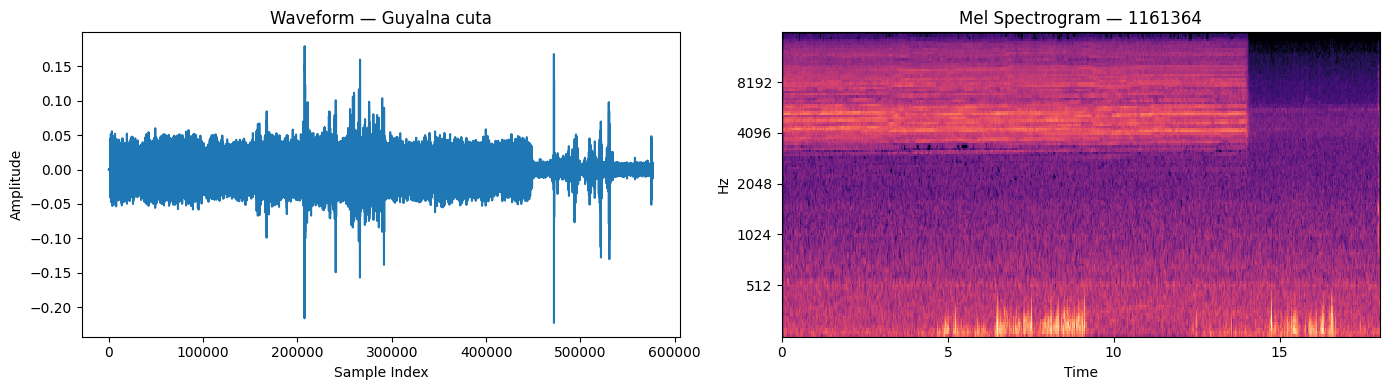

primary_label       : 1161364
common_name         : Guyalna cuta
scientific_name     : Guyalna cuta
class_name          : Insecta
collection          : iNat
rating              : 0.0
Duration            : 15.78s


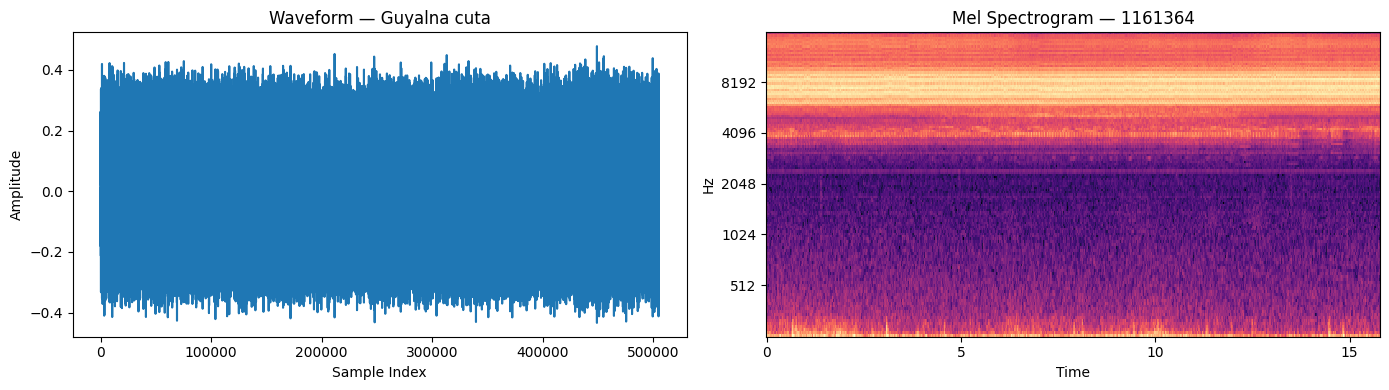

primary_label       : 1595929
common_name         : Uruguay Harlequin Frog
scientific_name     : Lysapsus limellum
class_name          : Amphibia
collection          : iNat
rating              : 0.0
Duration            : 15.70s


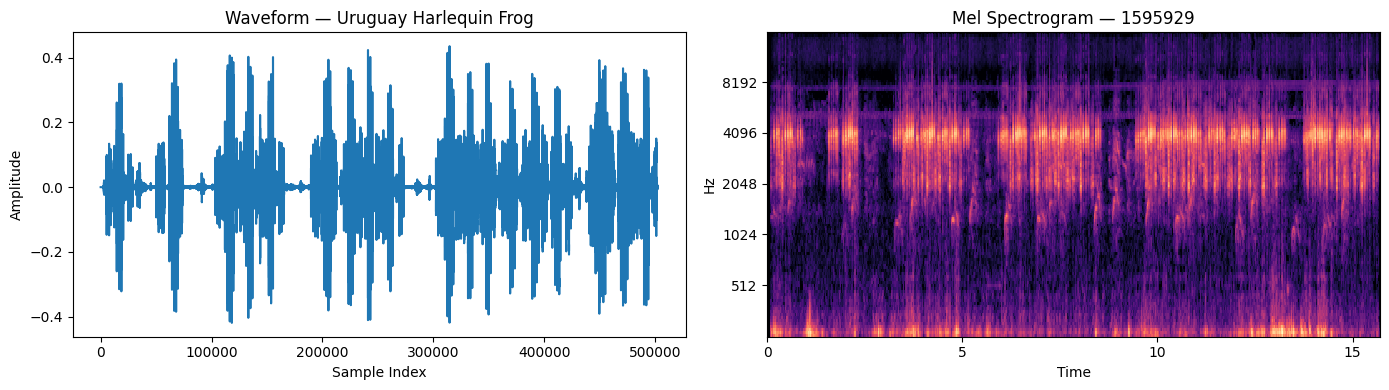

In [ ]:
def inspect_audio_sample(row_index, df, sr=32000):
    """Print metadata, waveform, and mel spectrogram for a given DataFrame row."""
    row = df.iloc[row_index]
    audio, sr = librosa.load(row['audio_path'], sr=sr, mono=True)

    print('=' * 70)
    for key in ['primary_label', 'common_name', 'scientific_name', 'class_name', 'collection', 'rating']:
        print(f'{key:20s}: {row[key]}')
    print(f'Duration            : {len(audio)/sr:.2f}s')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(audio)
    axes[0].set_title(f'Waveform — {row["common_name"]}')
    axes[0].set_xlabel('Sample Index')
    axes[0].set_ylabel('Amplitude')

    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmin=20, fmax=16000)
    librosa.display.specshow(
        librosa.power_to_db(mel, ref=np.max),
        sr=sr, x_axis='time', y_axis='mel', fmin=20, fmax=16000, ax=axes[1]
    )
    axes[1].set_title(f'Mel Spectrogram — {row["primary_label"]}')
    plt.tight_layout()
    plt.show()
    return row, audio, sr


for idx in [0, 10, 25]:
    inspect_audio_sample(idx, train_df)


## Step 9 - Global Spectrogram Configuration

All audio resampled to **32 kHz**. Each file chunked into **5-second windows** (160,000 samples).  
Each window transforms to a **(128 mel bins × 313 time frames)** spectrogram image.

| Parameter | Value | Rationale |
|---|---|---|
| Sample rate | 32,000 Hz | Competition standard |
| Window | 5 seconds | Covers most short wildlife calls |
| n_mels | 128 | Standard resolution for bioacoustics |
| fmin / fmax | 20 – 16,000 Hz | Full wildlife vocalization range |
| n_fft | 1024 | Frequency resolution |
| hop_length | 512 | ~16 ms per time frame |


In [ ]:
SR          = 32_000
DURATION    = 5
N_SAMPLES   = SR * DURATION    # 160,000 samples per chunk

N_FFT       = 1024
HOP_LENGTH  = 512
N_MELS      = 128
FMIN        = 20
FMAX        = 16_000

TIME_FRAMES = 1 + N_SAMPLES // HOP_LENGTH
print(f'Spectrogram shape per chunk: ({N_MELS}, {TIME_FRAMES})')   # (128, 313)

Spectrogram shape per chunk: (128, 313)


## Step 10 - Audio Processing Functions

Three reusable functions used by the Dataset class and during EDA:

- **`load_and_chunk_audio`** — loads `.ogg`, slices into 5s chunks, zero-pads short clips
- **`audio_to_melspec`** — converts raw audio to log-scaled mel spectrogram (dB)
- **`normalize_melspec`** — min-max scales to [0, 1] so all spectrograms share the same range

Chunks from first file: 3
  Chunk 0: audio (160000,) → mel (128, 313)
  Chunk 1: audio (160000,) → mel (128, 313)
  Chunk 2: audio (160000,) → mel (128, 313)


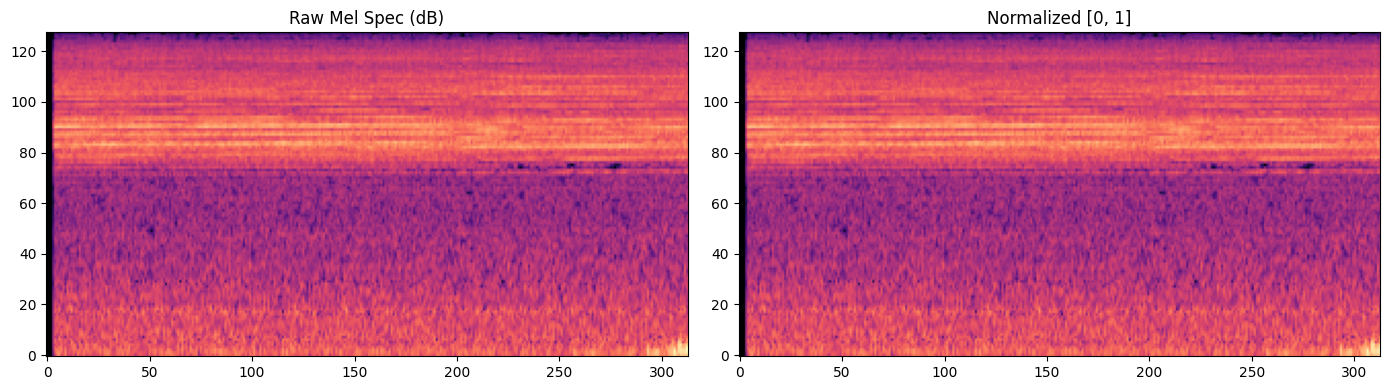

Raw   : min=-80.00, max=0.00
Normed: min=0.00, max=1.00


In [ ]:
def load_and_chunk_audio(filepath, sr=SR, duration=DURATION):
    """Load audio and split into fixed-length chunks. Zero-pads the last/only chunk if short."""
    audio, _ = librosa.load(filepath, sr=sr, mono=True)
    chunk_len = sr * duration
    if len(audio) < chunk_len:
        audio = np.concatenate([audio, np.zeros(chunk_len - len(audio))])
        return [audio]
    return [audio[s: s + chunk_len] for s in range(0, len(audio) - chunk_len + 1, chunk_len)]


def audio_to_melspec(audio_chunk, sr=SR):
    """Convert a raw audio chunk to a log-scaled mel spectrogram (dB)."""
    mel = librosa.feature.melspectrogram(
        y=audio_chunk, sr=sr, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX,
    )
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


def normalize_melspec(mel_db):
    """Min-max normalize a spectrogram to [0, 1]."""
    mel_min, mel_max = mel_db.min(), mel_db.max()
    return (mel_db - mel_min) / (mel_max - mel_min) if mel_max > mel_min else mel_db - mel_min


# Sanity check
test_chunks = load_and_chunk_audio(train_df.iloc[0]['audio_path'])
print(f'Chunks from first file: {len(test_chunks)}')
for i, c in enumerate(test_chunks):
    spec = audio_to_melspec(c)
    print(f'  Chunk {i}: audio {c.shape} → mel {spec.shape}')

# Raw vs normalised comparison
spec = audio_to_melspec(test_chunks[0])
spec_norm = normalize_melspec(spec)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(spec,      origin='lower', aspect='auto', cmap='magma')
axes[0].set_title('Raw Mel Spec (dB)')
axes[1].imshow(spec_norm, origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('Normalized [0, 1]')
plt.tight_layout()
plt.show()
print(f'Raw   : min={spec.min():.2f}, max={spec.max():.2f}')
print(f'Normed: min={spec_norm.min():.2f}, max={spec_norm.max():.2f}')


## Step 11 - Label Encoding

Convert string species labels (`primary_label`) to integer indices required by PyTorch's CrossEntropyLoss.  
The `LabelEncoder` is saved to Google Drive for reuse during inference.

In [ ]:
le = LabelEncoder()
le.fit(train_df['primary_label'])
train_df['label_idx'] = le.transform(train_df['primary_label'])

NUM_CLASSES = len(le.classes_)
print(f'Total classes : {NUM_CLASSES}')
print('Label mapping sample:')
for code, idx in zip(le.classes_[:5], range(5)):
    print(f'  {code} → {idx}')

with open(LABEL_ENCODER_PATH, 'wb') as f:
    pickle.dump(le, f)
print(f'\nLabel encoder saved → {LABEL_ENCODER_PATH}')

Total classes : 206
Label mapping sample:
  1161364 → 0
  116570 → 1
  1176823 → 2
  1595929 → 3
  209233 → 4

Label encoder saved → /content/drive/MyDrive/birdclef2026/models/label_encoder.pkl


## Step 12 - Stratified K-Fold Split

**StratifiedKFold (5 folds)** preserves class proportions in each split — essential given the significant  
class imbalance across 206 species. We train on Fold 0 here (~28,439 train / ~7,110 val).  

Set `FOLD = 1..4` to train other folds for a full ensemble submission.

In [ ]:
FOLD    = 0
N_FOLDS = 5

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
train_df['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(train_df, train_df['label_idx'])):
    train_df.loc[train_df.index[val_idx], 'fold'] = fold_idx

train_fold_df = train_df[train_df['fold'] != FOLD].reset_index(drop=True)
val_fold_df   = train_df[train_df['fold'] == FOLD].reset_index(drop=True)

print(f'Training samples  : {len(train_fold_df)}')
print(f'Validation samples: {len(val_fold_df)}')

Training samples  : 28439
Validation samples: 7110


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


## Step 13 - PyTorch Dataset & DataLoader

**`BirdCLEFDataset`** handles on-the-fly audio → spectrogram conversion:
- Loads `.ogg` and chunks into 5s windows
- During training: randomly picks a chunk (positional data augmentation)
- Converts `(128, 313)` spectrogram to `(3, 128, 313)` tensor (3-channel for EfficientNet)

**A100 tuning:** `BATCH_SIZE=64`, `NUM_WORKERS=4` — doubles throughput vs. local CPU settings.

In [ ]:
class BirdCLEFDataset(Dataset):
    """Loads audio on-the-fly, converts to normalised 3-channel mel spectrogram tensor."""

    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        chunks = load_and_chunk_audio(row['audio_path'])

        # Random chunk = cheap temporal augmentation during training
        chunk = chunks[np.random.randint(0, len(chunks))] if (self.augment and len(chunks) > 1) else chunks[0]

        spec        = normalize_melspec(audio_to_melspec(chunk))                # (128, 313)
        spec_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1)  # (3, 128, 313)
        label       = torch.tensor(row['label_idx'], dtype=torch.long)
        return spec_tensor, label


BATCH_SIZE  = 64    # Doubled from local — A100 has 40 GB VRAM
NUM_WORKERS = 4     # Parallel data loading

train_dataset = BirdCLEFDataset(train_fold_df, augment=True)
val_dataset   = BirdCLEFDataset(val_fold_df,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

batch_specs, batch_labels = next(iter(train_loader))
print(f'Batch spec shape  : {batch_specs.shape}')    # (64, 3, 128, 313)
print(f'Batch label shape : {batch_labels.shape}')   # (64,)


Train batches : 444
Val batches   : 112
Batch spec shape  : torch.Size([64, 3, 128, 313])
Batch label shape : torch.Size([64])


## Step 14 - Model Architecture (EfficientNet-B0)

**EfficientNet-B0** via `timm` with ImageNet pretrained weights.  
The final head is replaced with a `num_classes=206` layer.

Why EfficientNet-B0:
- Compound scaling efficiently balances depth, width, and resolution
- 4.2M parameters — fast to train and easy to iterate
- Competitive baseline in prior BirdCLEF competitions

Input shape: `(batch, 3, 128, 313)` — mono spectrogram replicated to 3 channels.

In [ ]:
class BirdCLEFModel(nn.Module):
    """EfficientNet-B0 backbone with custom classification head for wildlife species ID."""

    def __init__(self, num_classes, model_name='efficientnet_b0', pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained,
            num_classes=num_classes, in_chans=3,
        )

    def forward(self, x):
        return self.backbone(x)


model = BirdCLEFModel(num_classes=NUM_CLASSES).to(DEVICE)

with torch.no_grad():
    dummy = torch.randn(2, 3, 128, 313).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape    : {out.shape}')   # (2, 206)

print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Output shape    : torch.Size([2, 206])
Total parameters: 4,271,434


## Step 15 - Loss, Optimizer & Scheduler

| Component | Choice | Rationale |
|---|---|---|
| Loss | CrossEntropyLoss (label_smoothing=0.1) | Smoothing reduces overconfidence on noisy field recordings |
| Optimizer | AdamW (lr=1e-3, wd=1e-4) | Decoupled weight decay, strong default for fine-tuning |
| Scheduler | CosineAnnealingLR | Gradually decays lr to 1e-6 over all epochs |
| Epochs | 15 | Increased from 4 (local) — A100 makes this practical (~3–5 min/epoch) |

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

NUM_EPOCHS = 15

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('Loss      : CrossEntropyLoss (label_smoothing=0.1)')
print('Optimizer : AdamW  lr=1e-3, wd=1e-4')
print('Scheduler : CosineAnnealingLR')
print(f'Epochs    : {NUM_EPOCHS}')

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW  lr=1e-3, wd=1e-4
Scheduler : CosineAnnealingLR
Epochs    : 15


## Step 16 - Training & Validation Loop Functions

`train_one_epoch` — full pass over training set, computes loss + accuracy, updates weights.  
`validate` — full pass over validation set under `torch.no_grad()` for evaluation only.  

Both return `(avg_loss, accuracy)` for history logging.

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    """One training epoch with per-batch progress bar. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc='Training', leave=False)
    for batch_idx, (specs, labels) in enumerate(pbar):
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(specs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * specs.size(0)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update progress bar every batch
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{total_loss / ((batch_idx + 1) * loader.batch_size):.4f}',
        })

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


def validate(model, loader, criterion, device):
    """One validation epoch with progress bar. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc='Validating', leave=False)
    with torch.no_grad():
        for batch_idx, (specs, labels) in enumerate(pbar):
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * specs.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{total_loss / ((batch_idx + 1) * loader.batch_size):.4f}',
            })

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)

print('train_one_epoch() and validate() defined.')


train_one_epoch() and validate() defined.


## Step 17 - Training Run

Main training loop with:
- **Epoch-level logging** of train/val loss and accuracy
- **Best-model checkpointing** — saves to Google Drive on every validation loss improvement
- **Scheduler step** after each epoch



In [ ]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n{"="*60}')
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}')
    print(f'{"="*60}')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Epoch summary
    print(f'  Train Loss : {train_loss:.4f}  |  Train Acc : {train_acc:.4f}')
    print(f'  Val Loss   : {val_loss:.4f}  |  Val Acc   : {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f'  ✓ Best model saved → {MODEL_SAVE_PATH}')
    else:
        print(f'  – No improvement (best val loss: {best_val_loss:.4f})')

print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')


Epoch 01/15


  Train Loss : 3.0308  |  Train Acc : 0.4577
  Val Loss   : 2.4107  |  Val Acc   : 0.6114
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 02/15


  Train Loss : 2.3674  |  Train Acc : 0.6244
  Val Loss   : 2.1871  |  Val Acc   : 0.6647
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 03/15


  Train Loss : 2.1118  |  Train Acc : 0.6919
  Val Loss   : 2.0922  |  Val Acc   : 0.6962
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 04/15


  Train Loss : 1.9615  |  Train Acc : 0.7281
  Val Loss   : 2.0097  |  Val Acc   : 0.7300
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 05/15


...

  Train Loss : 1.3185  |  Train Acc : 0.8991
  Val Loss   : 1.8162  |  Val Acc   : 0.7785
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 12/15


  Train Loss : 1.2620  |  Train Acc : 0.9133
  Val Loss   : 1.8137  |  Val Acc   : 0.7859
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 13/15


  Train Loss : 1.2097  |  Train Acc : 0.9260
  Val Loss   : 1.8081  |  Val Acc   : 0.7865
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 14/15


  Train Loss : 1.1868  |  Train Acc : 0.9329
  Val Loss   : 1.8075  |  Val Acc   : 0.7857
  ✓ Best model saved → /content/drive/MyDrive/birdclef2026/models/efficientnet_b0_fold0.pth

Epoch 15/15


  Train Loss : 1.1723  |  Train Acc : 0.9363
  Val Loss   : 1.8077  |  Val Acc   : 0.7866
  – No improvement (best val loss: 1.8075)

Training complete. Best val loss: 1.8075


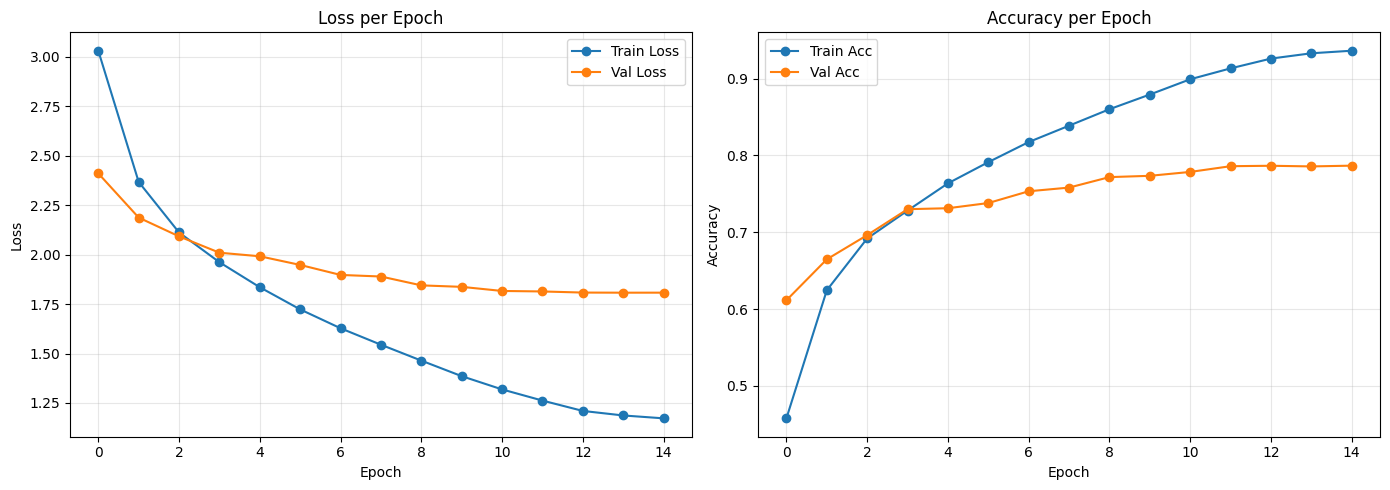

Training curves saved to Drive.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], marker='o', label='Train Loss')
ax1.plot(history['val_loss'],   marker='o', label='Val Loss')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], marker='o', label='Train Acc')
ax2.plot(history['val_acc'],   marker='o', label='Val Acc')
ax2.set_title('Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(DRIVE_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to Drive.')

In [ ]:
import torch, pickle, json
from pathlib import Path

# Make sure Drive is still mounted
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/birdclef2026/models')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save model weights
torch.save(model.state_dict(), DRIVE_DIR / 'efficientnet_b0_fold0.pth')
print(f'✓ Model weights saved')

# 2. Save full model (easier to load tomorrow)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss': best_val_loss,
    'history': history,
    'num_classes': NUM_CLASSES,
    'epoch': NUM_EPOCHS,
}, DRIVE_DIR / 'checkpoint_full.pth')
print(f'✓ Full checkpoint saved')

# 3. Save label encoder
with open(DRIVE_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print(f'✓ Label encoder saved')

# 4. Save config so you remember exact settings tomorrow
config = {
    'model_name':  'efficientnet_b0',
    'num_classes': NUM_CLASSES,
    'sr':          SR,
    'duration':    DURATION,
    'n_mels':      N_MELS,
    'n_fft':       N_FFT,
    'hop_length':  HOP_LENGTH,
    'fmin':        FMIN,
    'fmax':        FMAX,
    'batch_size':  BATCH_SIZE,
    'num_epochs':  NUM_EPOCHS,
    'best_val_loss': best_val_loss,
}
with open(DRIVE_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'✓ Config saved')

print(f'\nAll files saved to: {DRIVE_DIR}')
print('\nFiles in Drive:')
for f in sorted(DRIVE_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:40s} {size_mb:.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Model weights saved
✓ Full checkpoint saved
✓ Label encoder saved
✓ Config saved

All files saved to: /content/drive/MyDrive/birdclef2026/models

Files in Drive:
  checkpoint_full.pth                      51.7 MB
  config.json                              0.0 MB
  efficientnet_b0_fold0.pth                17.4 MB
  label_encoder.pkl                        0.0 MB


In [ ]:
import torch
import numpy as np
import librosa
import matplotlib.pyplot as plt

def predict_single_file(filepath, model, le, device, top_k=5):
    """
    Run inference on a single audio file.
    Returns top-k predicted species with confidence scores.
    """
    model.eval()

    # Load and chunk audio
    chunks = load_and_chunk_audio(filepath)
    print(f'File     : {filepath}')
    print(f'Chunks   : {len(chunks)} x 5s windows')

    all_probs = []

    with torch.no_grad():
        for i, chunk in enumerate(chunks):
            # Audio → spectrogram → tensor
            spec        = normalize_melspec(audio_to_melspec(chunk))
            spec_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1)
            spec_tensor = spec_tensor.unsqueeze(0).to(device)   # (1, 3, 128, 313)

            # Forward pass
            logits = model(spec_tensor)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
            all_probs.append(probs)

            # Per-chunk top prediction
            top_idx   = probs.argmax()
            top_label = le.inverse_transform([top_idx])[0]
            print(f'  Chunk {i}: {top_label} ({probs[top_idx]*100:.1f}%)')

    # Average probabilities across all chunks
    avg_probs = np.mean(all_probs, axis=0)

    # Top-k predictions
    top_k_idx    = avg_probs.argsort()[::-1][:top_k]
    top_k_labels = le.inverse_transform(top_k_idx)
    top_k_probs  = avg_probs[top_k_idx]

    print(f'\n── Top {top_k} Predictions (averaged across {len(chunks)} chunks) ──')
    for rank, (label, prob) in enumerate(zip(top_k_labels, top_k_probs), 1):
        bar = '█' * int(prob * 40)
        print(f'  {rank}. {label:20s} {prob*100:5.1f}%  {bar}')

    return top_k_labels, top_k_probs, avg_probs


print('predict_single_file() defined.')

predict_single_file() defined.


In [ ]:
# Pick 5 random samples from validation set to test
import random

test_samples = val_fold_df.sample(5, random_state=42).reset_index(drop=True)

print('='*60)
print('INFERENCE SANITY CHECK — Validation Samples')
print('='*60)

correct = 0
for i, row in test_samples.iterrows():
    print(f'\nSample {i+1}')
    print(f'True label : {row["primary_label"]} ({row["common_name"]})')

    top_labels, top_probs, _ = predict_single_file(
        filepath = row['audio_path'],
        model    = model,
        le       = le,
        device   = DEVICE,
        top_k    = 3,
    )

    is_correct = row['primary_label'] == top_labels[0]
    correct   += int(is_correct)
    print(f'Result     : {"✓ CORRECT" if is_correct else "✗ WRONG"}')
    print('-'*60)

print(f'\nAccuracy on 5 samples: {correct}/5')

INFERENCE SANITY CHECK — Validation Samples

Sample 1
True label : masgna1 (Masked Gnatcatcher)
File     : /content/data/birdclef-2026/train_audio/masgna1/XC663273.ogg
Chunks   : 10 x 5s windows
  Chunk 0: masgna1 (59.9%)
  Chunk 1: masgna1 (83.9%)
  Chunk 2: masgna1 (88.5%)
  Chunk 3: masgna1 (96.9%)
  Chunk 4: masgna1 (91.5%)
  Chunk 5: masgna1 (77.3%)
  Chunk 6: masgna1 (85.2%)
  Chunk 7: sobtyr1 (21.6%)
  Chunk 8: masgna1 (65.3%)
  Chunk 9: masgna1 (89.9%)

── Top 3 Predictions (averaged across 10 chunks) ──
  1. masgna1               75.5%  ██████████████████████████████
  2. sobtyr1                6.0%  ██
  3. trokin                 1.2%  
Result     : ✓ CORRECT
------------------------------------------------------------

Sample 2
True label : shtnig1 (Short-tailed Nighthawk)
File     : /content/data/birdclef-2026/train_audio/shtnig1/XC505156.ogg
Chunks   : 1 x 5s windows
  Chunk 0: whnjay1 (29.3%)

── Top 3 Predictions (averaged across 1 chunks) ──
  1. whnjay1               2


True label: 65377 — Lesser Tree Frog


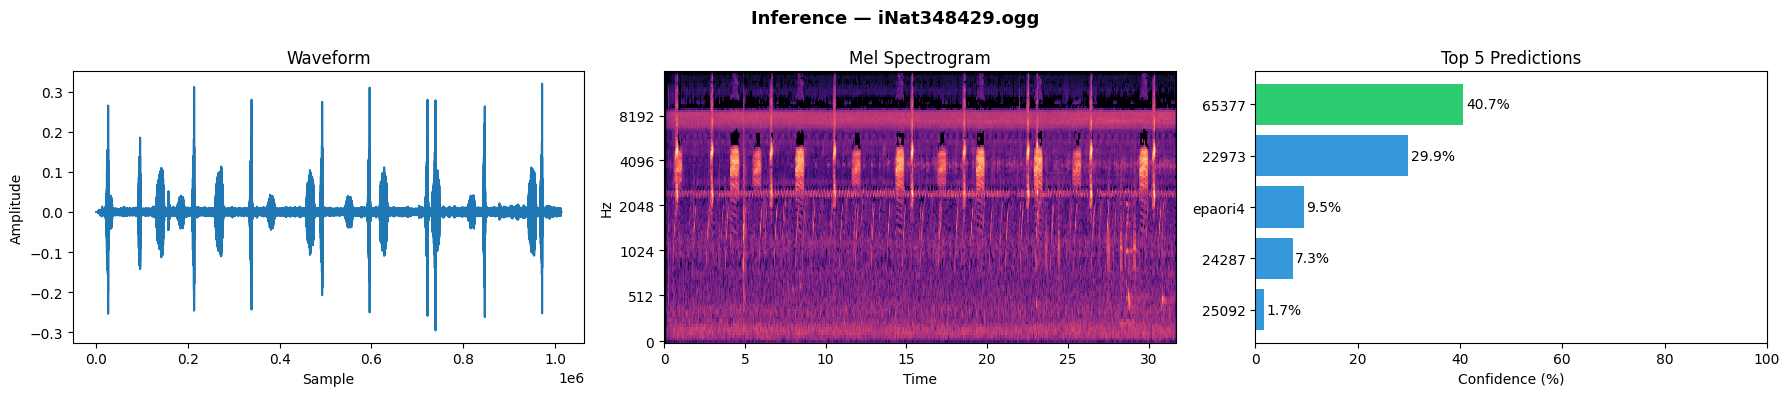


True label: epaori4 — Variable Oriole


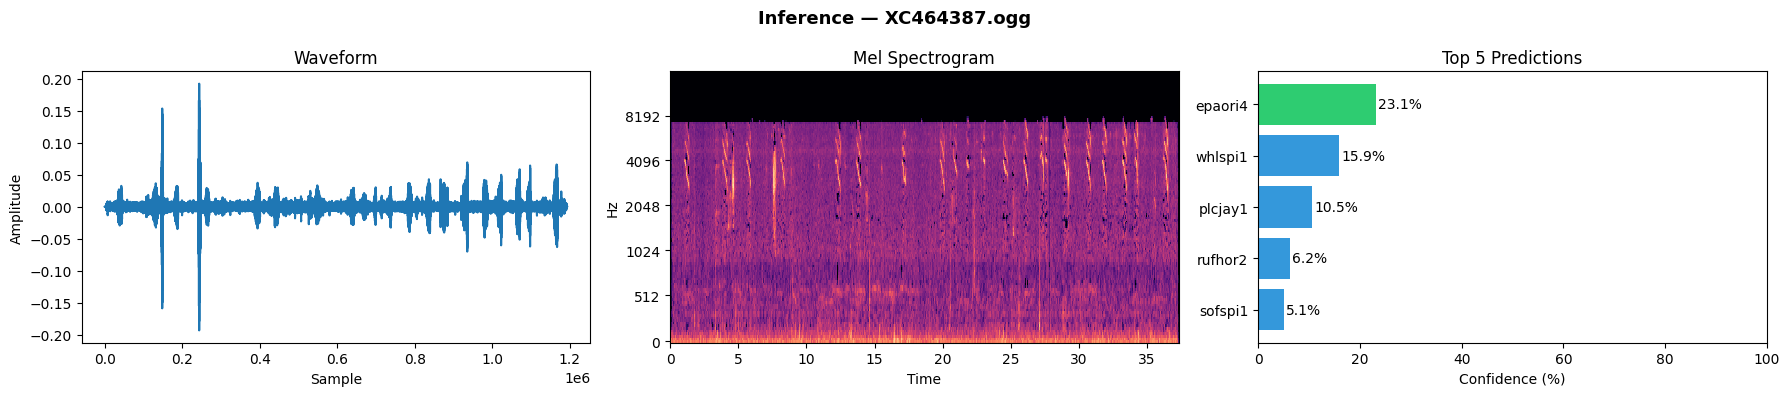


True label: rubthr1 — Rufous-bellied Thrush


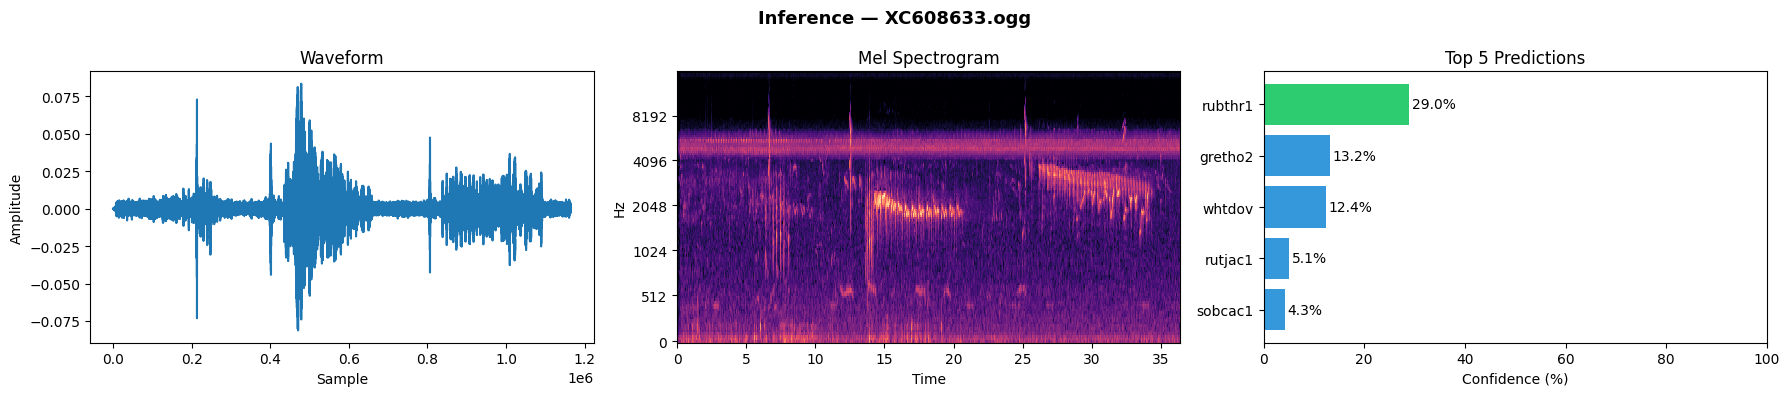

In [ ]:
def predict_and_visualize(filepath, model, le, device):
    """Predict and show waveform + spectrogram + confidence bar chart."""
    model.eval()

    audio, sr = librosa.load(filepath, sr=SR, mono=True)
    chunks    = load_and_chunk_audio(filepath)

    all_probs = []
    with torch.no_grad():
        for chunk in chunks:
            spec        = normalize_melspec(audio_to_melspec(chunk))
            spec_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).to(device)
            probs       = torch.softmax(model(spec_tensor), dim=1).cpu().numpy()[0]
            all_probs.append(probs)

    avg_probs    = np.mean(all_probs, axis=0)
    top5_idx     = avg_probs.argsort()[::-1][:5]
    top5_labels  = le.inverse_transform(top5_idx)
    top5_probs   = avg_probs[top5_idx]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Waveform
    axes[0].plot(audio)
    axes[0].set_title('Waveform')
    axes[0].set_xlabel('Sample')
    axes[0].set_ylabel('Amplitude')

    # Mel spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    librosa.display.specshow(
        librosa.power_to_db(mel, ref=np.max),
        sr=sr, x_axis='time', y_axis='mel', ax=axes[1]
    )
    axes[1].set_title('Mel Spectrogram')

    # Confidence bar chart
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(5)]
    axes[2].barh(top5_labels[::-1], top5_probs[::-1] * 100, color=colors[::-1])
    axes[2].set_xlabel('Confidence (%)')
    axes[2].set_title('Top 5 Predictions')
    axes[2].set_xlim(0, 100)
    for j, (prob, label) in enumerate(zip(top5_probs[::-1], top5_labels[::-1])):
        axes[2].text(prob * 100 + 0.5, j, f'{prob*100:.1f}%', va='center')

    plt.suptitle(f'Inference — {Path(filepath).name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return top5_labels, top5_probs


# Run on 3 random validation samples
for _, row in val_fold_df.sample(3, random_state=7).iterrows():
    print(f'\nTrue label: {row["primary_label"]} — {row["common_name"]}')
    predict_and_visualize(row['audio_path'], model, le, DEVICE)

In [ ]:
# Check accuracy on 100 validation samples — gives a more reliable number
from tqdm import tqdm

sample_df = val_fold_df.sample(100, random_state=42).reset_index(drop=True)

correct_top1 = 0
correct_top3 = 0
model.eval()

for _, row in tqdm(sample_df.iterrows(), total=100, desc='Running inference'):
    chunks    = load_and_chunk_audio(row['audio_path'])
    all_probs = []

    with torch.no_grad():
        for chunk in chunks:
            spec        = normalize_melspec(audio_to_melspec(chunk))
            spec_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).to(DEVICE)
            probs       = torch.softmax(model(spec_tensor), dim=1).cpu().numpy()[0]
            all_probs.append(probs)

    avg_probs  = np.mean(all_probs, axis=0)
    top3_idx   = avg_probs.argsort()[::-1][:3]
    top3_labels = le.inverse_transform(top3_idx)

    if row['primary_label'] == top3_labels[0]:
        correct_top1 += 1
    if row['primary_label'] in top3_labels:
        correct_top3 += 1

print(f'\n── Results on 100 validation samples ──')
print(f'Top-1 Accuracy : {correct_top1}/100  ({correct_top1:.1f}%)')
print(f'Top-3 Accuracy : {correct_top3}/100  ({correct_top3:.1f}%)')

Running inference: 100%|██████████| 100/100 [00:17<00:00,  5.87it/s]


── Results on 100 validation samples ──
Top-1 Accuracy : 85/100  (85.0%)
Top-3 Accuracy : 89/100  (89.0%)
